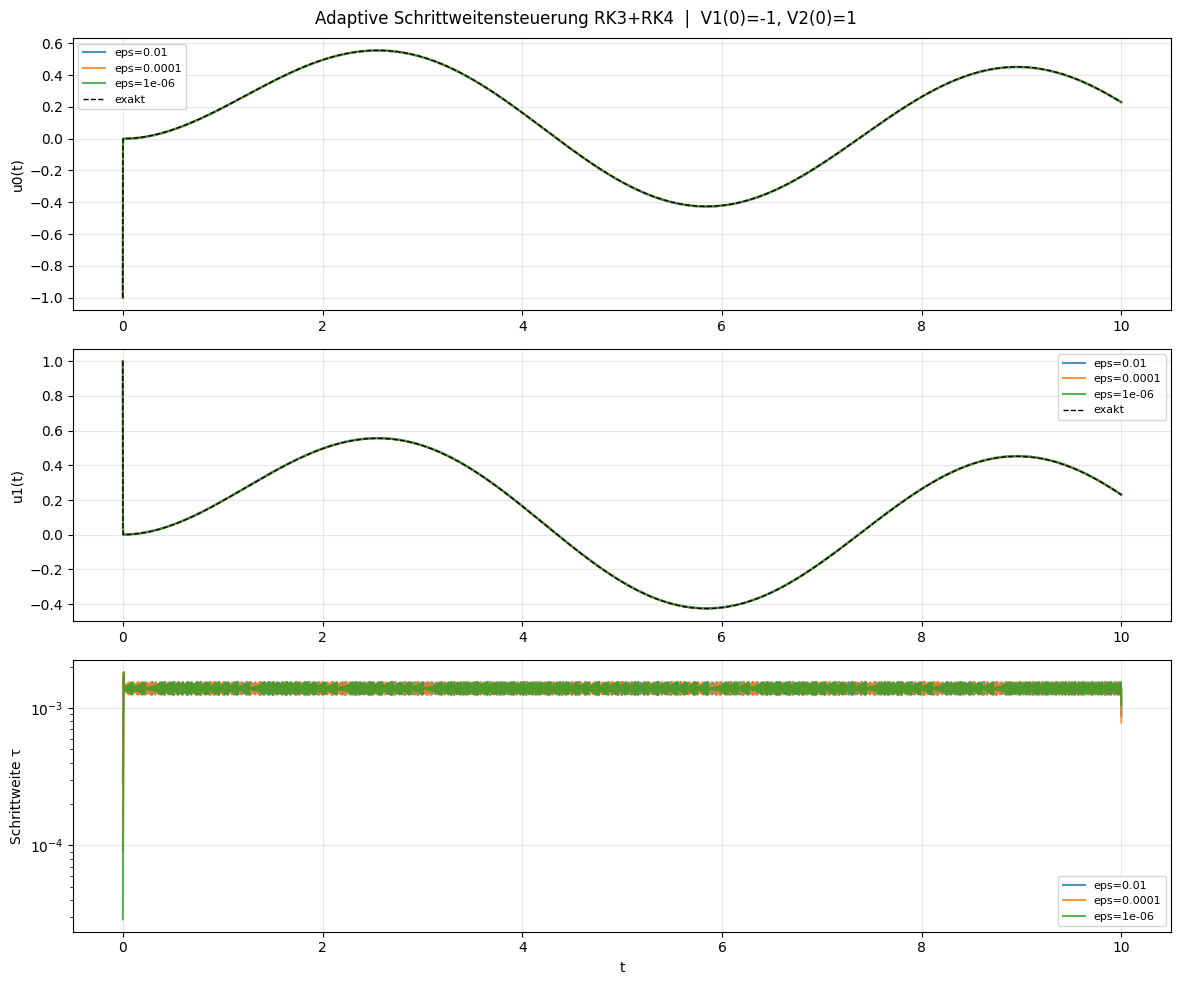

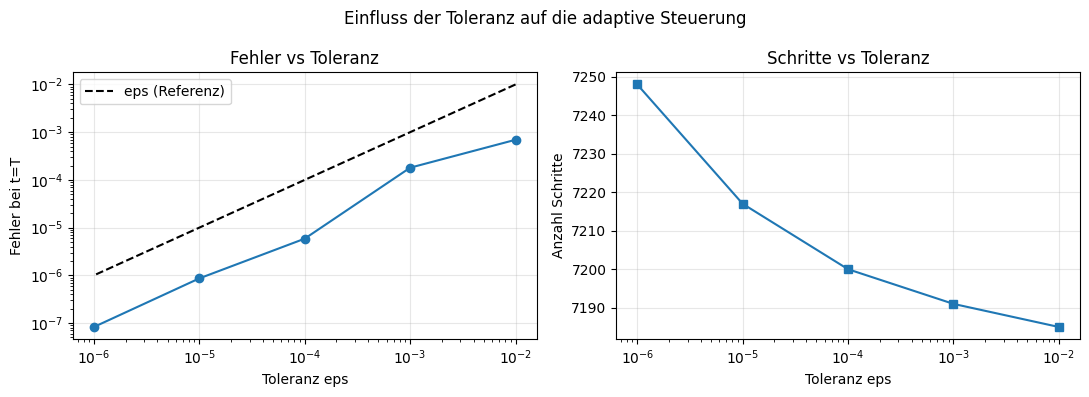

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# RungeKutta
# =============================================================================

class RungeKutta:
    def __init__(self, A, b, c, ko=1):
        self.A = A
        self.b = b
        self.c = c
        self.ko = ko
        self.s = len(b)
        self.explicit = np.allclose(A, np.tril(A, k=-1))

    def step(self, t, u, tau, f):
        k = np.zeros((self.s, len(u)))
        for i in range(self.s):
            u_stage = u + tau * self.A[i, :i] @ k[:i]
            k[i] = f(t + self.c[i] * tau, u_stage)
        return u + tau * self.b @ k


ExplicitEuler = RungeKutta(
    A=np.array([[0]]),
    b=np.array([1]),
    c=np.array([0]),
    ko=1
)

ImprovedEuler = RungeKutta(
    A=np.array([[0, 0],
                [1, 0]]),
    b=np.array([0.5, 0.5]),
    c=np.array([0, 1]),
    ko=2
)

RK3 = RungeKutta(
    A=np.array([[0,   0,   0],
                [1/3, 0,   0],
                [0,   2/3, 0]]),
    b=np.array([1/4, 0, 3/4]),
    c=np.array([0, 1/3, 2/3]),
    ko=3
)

RK4 = RungeKutta(
    A=np.array([[0,   0,   0,   0],
                [0.5, 0,   0,   0],
                [0,   0.5, 0,   0],
                [0,   0,   1,   0]]),
    b=np.array([1/6, 1/3, 1/3, 1/6]),
    c=np.array([0, 0.5, 0.5, 1]),
    ko=4
)


# =============================================================================
# Adaptive Solver
# =============================================================================

class adaptive_solver:
    def __init__(self, m1, m2, eps, taumin, taumax, rho=0.9, q=2):
        '''
        m1:     erstes Verfahren (niedrigere Ordnung)
        m2:     zweites Verfahren (höhere Ordnung)
        eps:    Fehlertoleranz
        taumin: minimale Schrittweite
        taumax: maximale Schrittweite
        rho:    Sicherheitsfaktor
        q:      maximaler Vergrößerungsfaktor für tau
        '''
        self.m1 = m1
        self.m2 = m2
        self.eps = eps
        self.taumin = taumin
        self.taumax = taumax
        self.rho = rho
        self.q = q
        self.order = min(self.m1.ko, self.m2.ko)

    def solve(self, f, u0, t0, tend):
        t = t0
        u = u0.copy()
        tau = self.taumax

        ts = [t]
        us = [u.copy()]
        taus = []

        while t < tend:
            tau = min(tau, tend - t)
            tau = max(tau, self.taumin)

            u1 = self.m1.step(t, u, tau, f)
            u2 = self.m2.step(t, u, tau, f)

            err = np.linalg.norm(u1 - u2)

            if err <= self.eps or tau <= self.taumin:
                t += tau
                u = u2
                ts.append(t)
                us.append(u.copy())
                taus.append(tau)

            # tau_neu = rho * tau * (eps / err)^(1/(p+1))
            if err > 0:
                tau_new = self.rho * tau * (self.eps / err) ** (1 / (self.order + 1))
            else:
                tau_new = self.q * tau

            tau = np.clip(tau_new, self.taumin, min(self.q * tau, self.taumax))

        return np.array(ts), np.array(us), np.array(taus)


# =============================================================================
# Schaltkreis (Aufgabe 7)
# =============================================================================

omega = 1
M = np.array([[-1001, 1000], [1000, -1000]])

def f(t, U):
    return M @ U + np.array([np.sin(omega * t), 0])

# exakte Lösung
MM = np.array([[1001, -1000, -omega, 0],
               [omega, 0, 1001, -1000],
               [-1000, 1000, 0, -omega],
               [0, omega, -1000, 1000]])
coefs = np.linalg.inv(MM) @ np.array([1, 0, 0, 0])
lams, evecs = np.linalg.eig(-M)

def exact(t, u0):
    scaling = -np.linalg.inv(evecs) @ (np.array([coefs[2], coefs[3]]) - u0)
    u1 = (coefs[0]*np.sin(omega*t) + coefs[2]*np.cos(omega*t)
          + scaling[0]*evecs[0,0]*np.exp(-lams[0]*t)
          + scaling[1]*evecs[0,1]*np.exp(-lams[1]*t))
    u2 = (coefs[1]*np.sin(omega*t) + coefs[3]*np.cos(omega*t)
          + scaling[0]*evecs[1,0]*np.exp(-lams[0]*t)
          + scaling[1]*evecs[1,1]*np.exp(-lams[1]*t))
    return np.real(np.array([u1, u2]))


# =============================================================================
# Plots
# =============================================================================

u0 = np.array([-1.0, 1.0])
t0, T = 0, 10

# --- Plot 1: Adaptive Lösung für verschiedene Toleranzen ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for eps, color in [(1e-2, 'C0'), (1e-4, 'C1'), (1e-6, 'C2')]:
    solver = adaptive_solver(RK3, RK4, eps=eps, taumin=1e-8, taumax=1.0)
    ts, us, taus = solver.solve(f, u0, t0, T)
    axes[0].plot(ts, us[:, 0], color=color, label=f'eps={eps}', alpha=0.8)
    axes[1].plot(ts, us[:, 1], color=color, label=f'eps={eps}', alpha=0.8)
    axes[2].semilogy(ts[:-1], taus, color=color, label=f'eps={eps}', alpha=0.8)

t_fine = np.linspace(t0, T, 5000)
u_ex = np.array([exact(t, u0) for t in t_fine])
axes[0].plot(t_fine, u_ex[:, 0], 'k--', lw=1, label='exakt')
axes[1].plot(t_fine, u_ex[:, 1], 'k--', lw=1, label='exakt')

axes[0].set_ylabel('u0(t)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].set_ylabel('u1(t)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[2].set_ylabel('Schrittweite τ')
axes[2].set_xlabel('t')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
fig.suptitle('Adaptive Schrittweitensteuerung RK3+RK4  |  V1(0)=-1, V2(0)=1', fontsize=12)
plt.tight_layout()
plt.savefig('aufgabe14_adaptiv.png', dpi=150)

# --- Plot 2: Fehler und Schritte vs Toleranz ---
fig2, ax2 = plt.subplots(1, 2, figsize=(11, 4))
epsilons = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
n_steps, errors = [], []

for eps in epsilons:
    solver = adaptive_solver(RK3, RK4, eps=eps, taumin=1e-8, taumax=1.0)
    ts, us, taus = solver.solve(f, u0, t0, T)
    n_steps.append(len(ts))
    errors.append(np.linalg.norm(us[-1] - exact(T, u0)))

ax2[0].loglog(epsilons, errors, 'o-')
ax2[0].loglog(epsilons, epsilons, 'k--', label='eps (Referenz)')
ax2[0].set_xlabel('Toleranz eps')
ax2[0].set_ylabel('Fehler bei t=T')
ax2[0].set_title('Fehler vs Toleranz')
ax2[0].legend()
ax2[0].grid(True, alpha=0.3)

ax2[1].semilogx(epsilons, n_steps, 's-')
ax2[1].set_xlabel('Toleranz eps')
ax2[1].set_ylabel('Anzahl Schritte')
ax2[1].set_title('Schritte vs Toleranz')
ax2[1].grid(True, alpha=0.3)

fig2.suptitle('Einfluss der Toleranz auf die adaptive Steuerung', fontsize=12)
plt.tight_layout()
plt.savefig('aufgabe14_toleranz.png', dpi=150)

plt.show()